In [1]:
import pandas as pd
import os

# 1. Path to your file
file_path = '/kaggle/input/datasets/saurabhbadole/breast-cancer-wisconsin-state/breast-cancer-wisconsin.data' 

# 2. Assign the result to df
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("DataFrame successfully loaded.")
else:
    print("File not found. Check your path using os.walk() again.")

DataFrame successfully loaded.


In [2]:
df.head()
df.describe()
df.isnull().sum()

1000025    0
5          0
1          0
1.1        0
1.2        0
2          0
1.3        0
3          0
1.4        0
1.5        0
2.1        0
dtype: int64

<Axes: >

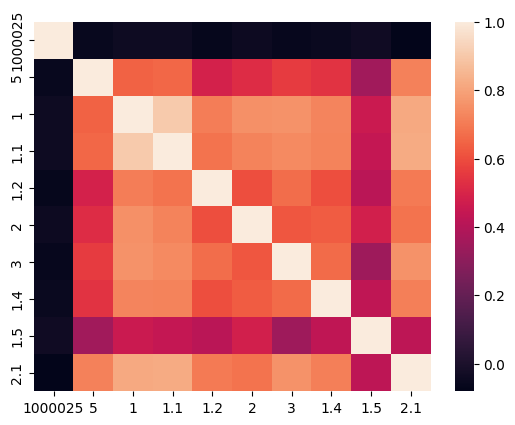

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True))

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load data
file_path ='/kaggle/input/datasets/saurabhbadole/breast-cancer-wisconsin-state/breast-cancer-wisconsin.data'
df= pd.read_csv(file_path ,header= None)

df.columns = ['id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape', 
              'marg_adhesion', 'single_epith_size', 'bare_nuclei', 
              'bland_chrom', 'norm_nucleoli', 'mitoses', 'class']


print(df.head())

import numpy as np
df= df.replace('?', np.nan)
df =df.dropna()
print(df)

        id  clump_thickness  unif_cell_size  unif_cell_shape  marg_adhesion  \
0  1000025                5               1                1              1   
1  1002945                5               4                4              5   
2  1015425                3               1                1              1   
3  1016277                6               8                8              1   
4  1017023                4               1                1              3   

   single_epith_size bare_nuclei  bland_chrom  norm_nucleoli  mitoses  class  
0                  2           1            3              1        1      2  
1                  7          10            3              2        1      2  
2                  2           2            3              1        1      2  
3                  3           4            3              7        1      2  
4                  2           1            3              1        1      2  
          id  clump_thickness  unif_cell_size  unif

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
X= df.drop(['id','class'], axis=1)
y= df['class']
X_train , X_test , y_train, y_test = train_test_split(X, y, random_state=40, test_size=0.3)
model= RandomForestClassifier()
model.fit(X_train,y_train)
print('Accuracy:' , model.score(X_test, y_test))

Accuracy: 0.9707317073170731


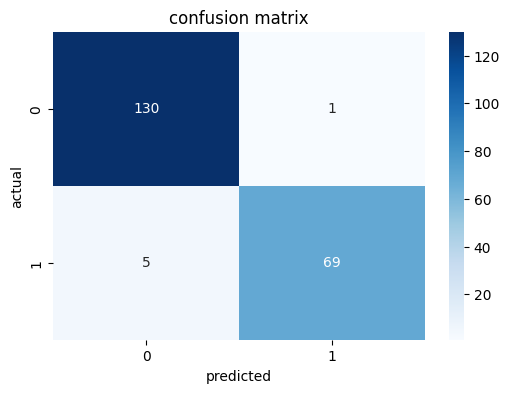

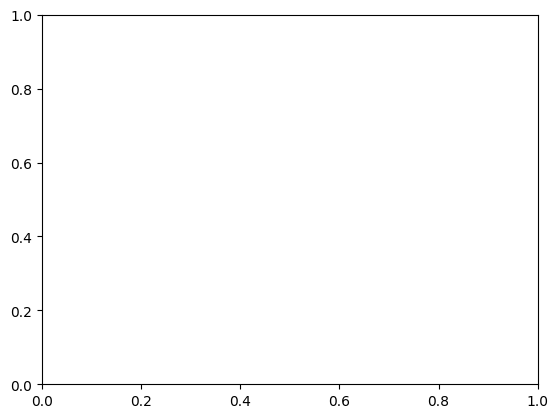

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_predict= model.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot =True, fmt= 'd', cmap= "Blues")
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title("confusion matrix")
plt.show()

sns.barplot()
sns.kdeplot()
plt.show()

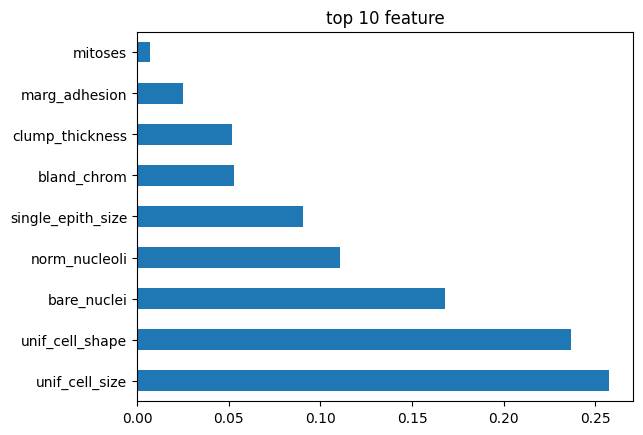

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index= X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title('top 10 feature')
plt.show()

In [18]:
print("score:", model.score(X_train, y_train))
print("score:", model.score(X_test, y_test))

score: 1.0
score: 0.9707317073170731


In [23]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model ,X,y , cv=7)
print("Average Cross-Validation Accuracy:", scores)
print("Average Cross-Validation Accuracy:", scores.mean())


Average Cross-Validation Accuracy: [0.92857143 0.97959184 0.93877551 0.97959184 0.96907216 0.97938144
 0.98969072]
Average Cross-Validation Accuracy: 0.9663821345916865
